# Notebook 03 — SARIMA, Auto-SARIMA, and SARIMAX

**Goal:** Implement the classical statistical models.

- **SARIMA**: seasonal ARIMA with manual parameters
- **Auto-SARIMA**: parameters chosen automatically
- **SARIMAX**: SARIMA + calendar exogenous features

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm
import joblib
from data_loader import get_monthly_total, train_test_split
from evaluation import evaluate

plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
y = get_monthly_total('../data/Tourism_MOM_Dataset.csv')
train, test = train_test_split(y, '2025-01-01')
results = pd.read_csv('../results/model_results.csv').to_dict('records')

## Step 1: SARIMA(1,1,1)(1,1,1,12)

The (1,1,1) handles non-seasonal trend; (1,1,1,12) handles the 12-month seasonal cycle.

In [3]:
sarima = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_fc = sarima.forecast(len(test))
results.append(evaluate(test, sarima_fc, 'SARIMA'))

SARIMA                          MAE=   42,083  RMSE=   48,964  MAPE= 22.89%


## Step 2: Auto-SARIMA

Automatically searches for the best (p,d,q)(P,D,Q) parameters. Takes ~1 minute.

In [4]:
auto = pm.auto_arima(train, seasonal=True, m=12, stepwise=True,
                     suppress_warnings=True, error_action='ignore')
print('Best order:', auto.order, auto.seasonal_order)
auto_fc = pd.Series(auto.predict(len(test)), index=test.index)
results.append(evaluate(test, auto_fc, 'Auto-SARIMA'))
joblib.dump({'order': (1,1,1), 'seasonal_order': (1,1,1,12)}, '../results/sarima_params.pkl')

Best order: (3, 0, 0) (1, 0, 0, 12)
Auto-SARIMA                     MAE=   27,109  RMSE=   38,139  MAPE= 12.36%


['../results/sarima_params.pkl']

## Step 3: SARIMAX (with calendar exogenous features)

We add month, quarter, and a time index as exogenous regressors — engineered from the dataset itself.

In [5]:
ex = pd.DataFrame({'month': y.index.month, 'quarter': y.index.quarter, 't': np.arange(len(y))}, index=y.index)
ex_tr, ex_te = ex[ex.index < '2025-01-01'], ex[ex.index >= '2025-01-01']
sarimax = SARIMAX(train, exog=ex_tr, order=(1,1,1), seasonal_order=(1,1,1,12),
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarimax_fc = sarimax.forecast(len(test), exog=ex_te)
results.append(evaluate(test, sarimax_fc, 'SARIMAX'))

SARIMAX                         MAE=   42,083  RMSE=   48,964  MAPE= 22.89%


## Step 4: Plot all SARIMA-family forecasts

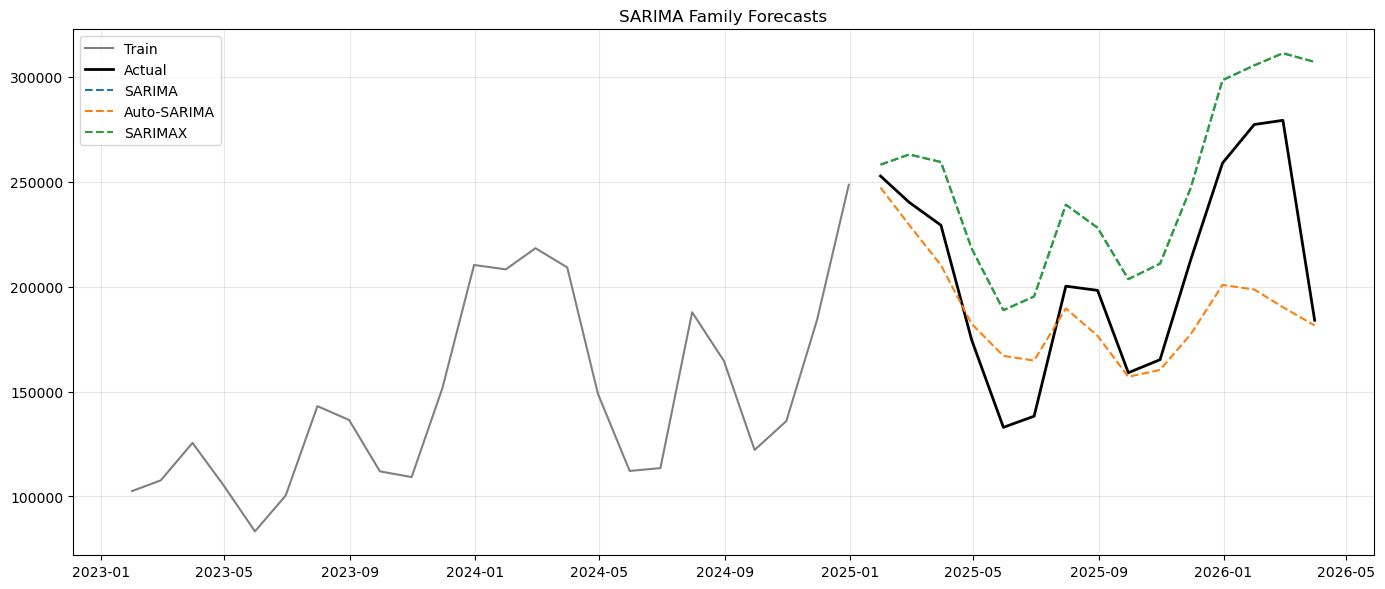

In [6]:
plt.figure()
plt.plot(train.index[-24:], train.values[-24:], label='Train', color='gray')
plt.plot(test.index, test.values, label='Actual', color='black', linewidth=2)
plt.plot(test.index, sarima_fc.values, '--', label='SARIMA')
plt.plot(test.index, auto_fc.values, '--', label='Auto-SARIMA')
plt.plot(test.index, sarimax_fc.values, '--', label='SARIMAX')
plt.title('SARIMA Family Forecasts'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('../results/03_sarima.png', dpi=150); plt.show()

In [7]:
pd.DataFrame(results).to_csv('../results/model_results.csv', index=False)
print('Saved. Move to 04_xgboost_model.ipynb')

Saved. Move to 04_xgboost_model.ipynb
